Aula de Linha de Regressão


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.metrics import mean_absolute_error
import numpy as np

Importando dataset iris do conjunto de datasets salvos no SKlearn

In [3]:
#df = pd.read_csv('iris.csv', sep=',') Essa eh a forma manual
iris = datasets.load_iris()

In [4]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [5]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Criando subplot para testar a distribuição dos elementos

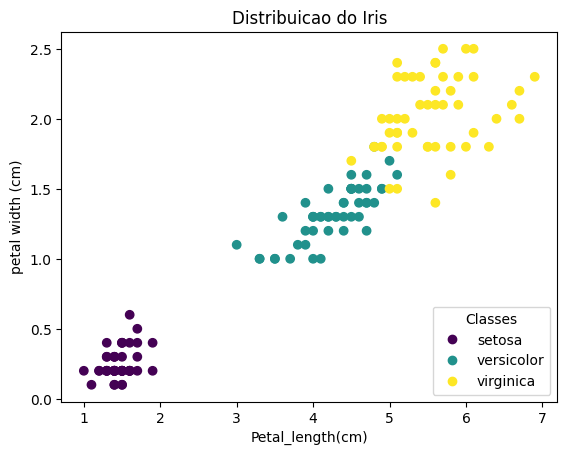

In [6]:
fig, ax = plt.subplots()
scatter = ax.scatter(iris.data[:,2], iris.data[:,3], c=iris.target)
ax.set_title('Distribuicao do Iris')
ax.set_xlabel('Petal_length(cm)')
#ax.set_ylabel('Petal_width(cm)') #opção tradicional
ax.set_ylabel(iris.feature_names[3]) #outra opção
ax.legend(scatter.legend_elements()[0], iris.target_names,
           loc="lower right", title="Classes")
plt.show()


Regressão Linear

In [7]:
X = iris.data[:,2].reshape(-1, 1) #petal_length
y = iris.data[:,3] #petal_width
especie = iris.target

In [8]:
print(X)

[[1.4]
 [1.4]
 [1.3]
 [1.5]
 [1.4]
 [1.7]
 [1.4]
 [1.5]
 [1.4]
 [1.5]
 [1.5]
 [1.6]
 [1.4]
 [1.1]
 [1.2]
 [1.5]
 [1.3]
 [1.4]
 [1.7]
 [1.5]
 [1.7]
 [1.5]
 [1. ]
 [1.7]
 [1.9]
 [1.6]
 [1.6]
 [1.5]
 [1.4]
 [1.6]
 [1.6]
 [1.5]
 [1.5]
 [1.4]
 [1.5]
 [1.2]
 [1.3]
 [1.4]
 [1.3]
 [1.5]
 [1.3]
 [1.3]
 [1.3]
 [1.6]
 [1.9]
 [1.4]
 [1.6]
 [1.4]
 [1.5]
 [1.4]
 [4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]
 [4.5]
 [4.7]
 [3.3]
 [4.6]
 [3.9]
 [3.5]
 [4.2]
 [4. ]
 [4.7]
 [3.6]
 [4.4]
 [4.5]
 [4.1]
 [4.5]
 [3.9]
 [4.8]
 [4. ]
 [4.9]
 [4.7]
 [4.3]
 [4.4]
 [4.8]
 [5. ]
 [4.5]
 [3.5]
 [3.8]
 [3.7]
 [3.9]
 [5.1]
 [4.5]
 [4.5]
 [4.7]
 [4.4]
 [4.1]
 [4. ]
 [4.4]
 [4.6]
 [4. ]
 [3.3]
 [4.2]
 [4.2]
 [4.2]
 [4.3]
 [3. ]
 [4.1]
 [6. ]
 [5.1]
 [5.9]
 [5.6]
 [5.8]
 [6.6]
 [4.5]
 [6.3]
 [5.8]
 [6.1]
 [5.1]
 [5.3]
 [5.5]
 [5. ]
 [5.1]
 [5.3]
 [5.5]
 [6.7]
 [6.9]
 [5. ]
 [5.7]
 [4.9]
 [6.7]
 [4.9]
 [5.7]
 [6. ]
 [4.8]
 [4.9]
 [5.6]
 [5.8]
 [6.1]
 [6.4]
 [5.6]
 [5.1]
 [5.6]
 [6.1]
 [5.6]
 [5.5]
 [4.8]
 [5.4]
 [5.6]
 [5.1]
 [5.1]

In [9]:
print(iris.data[:,2])

[1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 1.5 1.6 1.4 1.1 1.2 1.5 1.3 1.4
 1.7 1.5 1.7 1.5 1.  1.7 1.9 1.6 1.6 1.5 1.4 1.6 1.6 1.5 1.5 1.4 1.5 1.2
 1.3 1.4 1.3 1.5 1.3 1.3 1.3 1.6 1.9 1.4 1.6 1.4 1.5 1.4 4.7 4.5 4.9 4.
 4.6 4.5 4.7 3.3 4.6 3.9 3.5 4.2 4.  4.7 3.6 4.4 4.5 4.1 4.5 3.9 4.8 4.
 4.9 4.7 4.3 4.4 4.8 5.  4.5 3.5 3.8 3.7 3.9 5.1 4.5 4.5 4.7 4.4 4.1 4.
 4.4 4.6 4.  3.3 4.2 4.2 4.2 4.3 3.  4.1 6.  5.1 5.9 5.6 5.8 6.6 4.5 6.3
 5.8 6.1 5.1 5.3 5.5 5.  5.1 5.3 5.5 6.7 6.9 5.  5.7 4.9 6.7 4.9 5.7 6.
 4.8 4.9 5.6 5.8 6.1 6.4 5.6 5.1 5.6 6.1 5.6 5.5 4.8 5.4 5.6 5.1 5.1 5.9
 5.7 5.2 5.  5.2 5.4 5.1]


Fazendo train teste split tradicional com elemento de especie

In [10]:
X_treino, X_teste, y_treino, y_teste, especie_treino, especie_teste = train_test_split(X, y, especie, test_size=0.2, random_state=40)

Treinando o modelo

In [11]:
regressao = linear_model.LinearRegression()
regressao.fit(X_treino, y_treino)
y_pred = regressao.predict(X_teste)

Gerando resultado

In [12]:
r2 = r2_score(y_teste, y_pred)
mse = mean_squared_error(y_teste, y_pred)
rmse = mse ** 0.5
print (r2, mse, rmse)

0.9301094595331071 0.039918370468446235 0.19979582194942475


Criando máscara

In [13]:
setosa = especie_teste == 0 
versicolor = especie_teste == 1 
virginica = especie_teste == 2

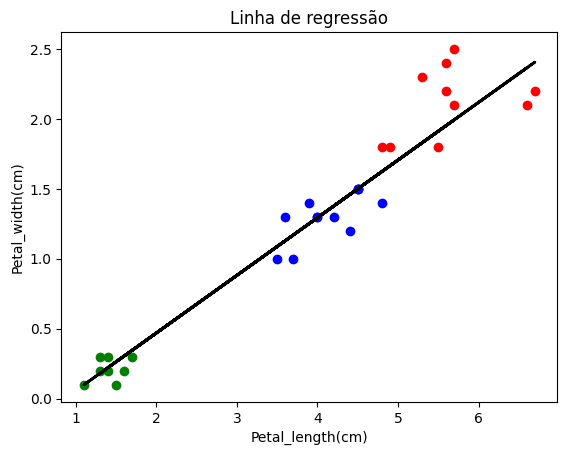

In [14]:
plt.scatter(X_teste[setosa], y_teste[setosa], 
            color='green', label='setosa')
plt.scatter(X_teste[versicolor], y_teste[versicolor], 
            color='blue', label='versicolor')
plt.scatter(X_teste[virginica], y_teste[virginica], 
            color='red', label='virginica')
plt.plot(X_teste, y_pred, color='black', linewidth=2, 
         label='Linha de Regressão')
plt.xlabel('Petal_length(cm)')
plt.ylabel('Petal_width(cm)')
plt.title('Linha de regressão')
plt.show()

Treinamento dos modelos

In [15]:
linear = linear_model.LinearRegression()
linear.fit(X_treino, y_treino)
y_pred_linear = linear.predict(X_teste)

svm = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svm.fit(X_treino, y_treino)
y_pred_svm = svm.predict(X_teste)

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    random_state=40
)

gpr.fit(X_treino, y_treino)
y_pred_gpr = gpr.predict(X_teste)

c:\Users\LoraxCrazy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\LoraxCrazy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Cálculo das métricas

In [16]:
resultados = {
    "Modelo": [],
    "R2": [],
    "MAE": [],
    "MSE": [],
    "RMSE": []
}

modelos = {
    "Linear": y_pred_linear,
    "SVM": y_pred_svm,
    "GPR": y_pred_gpr
}

for nome, pred in modelos.items():

    r2 = r2_score(y_teste, pred)
    mae = mean_absolute_error(y_teste, pred)
    mse = mean_squared_error(y_teste, pred)
    rmse = np.sqrt(mse)

    resultados["Modelo"].append(nome)
    resultados["R2"].append(r2)
    resultados["MAE"].append(mae)
    resultados["MSE"].append(mse)
    resultados["RMSE"].append(rmse)

df_resultados = pd.DataFrame(resultados)

print(df_resultados)

   Modelo        R2       MAE       MSE      RMSE
0  Linear  0.930109  0.145940  0.039918  0.199796
1     SVM  0.950713  0.138442  0.028150  0.167781
2     GPR  0.530505  0.273469  0.268155  0.517837


Gráfico comparando as curvas dos modelos

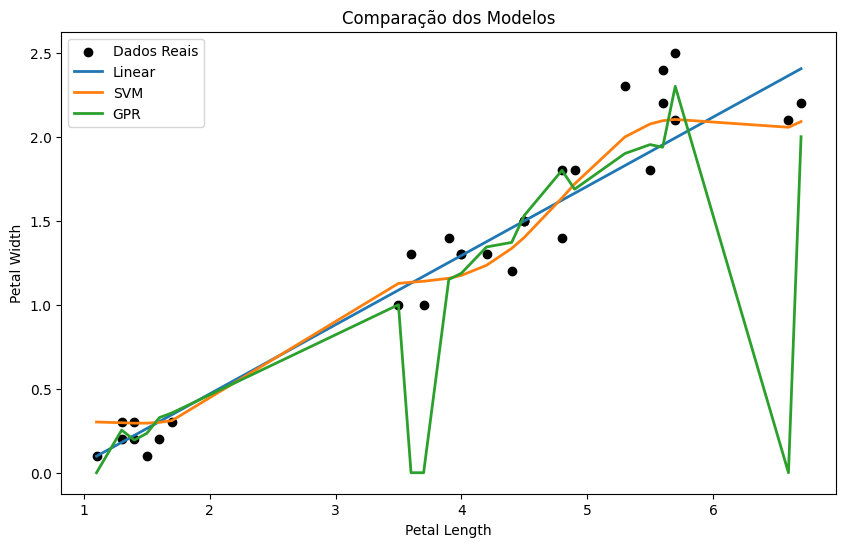

In [17]:
ordem = np.argsort(X_teste.flatten())

plt.figure(figsize=(10,6))

plt.scatter(X_teste, y_teste,
            color='black',
            label='Dados Reais')

plt.plot(
    X_teste[ordem],
    y_pred_linear[ordem],
    label='Linear',
    linewidth=2
)

plt.plot(
    X_teste[ordem],
    y_pred_svm[ordem],
    label='SVM',
    linewidth=2
)

plt.plot(
    X_teste[ordem],
    y_pred_gpr[ordem],
    label='GPR',
    linewidth=2
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Comparação dos Modelos')
plt.legend()
plt.show()

Gráfico comparativo de R²

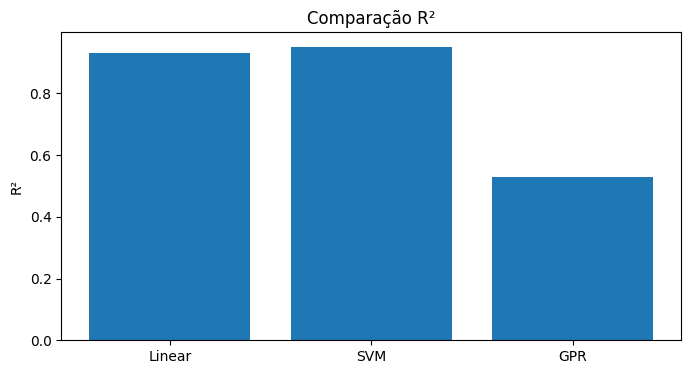

In [18]:
plt.figure(figsize=(8,4))
plt.bar(df_resultados["Modelo"], df_resultados["R2"])
plt.title("Comparação R²")
plt.ylabel("R²")
plt.show()

Gráfico comparativo de MAE

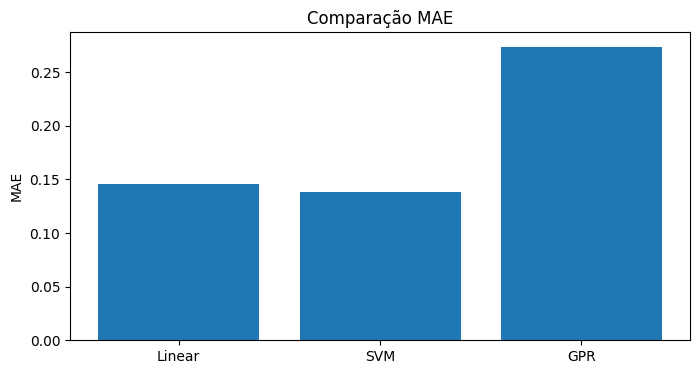

In [19]:
plt.figure(figsize=(8,4))
plt.bar(df_resultados["Modelo"], df_resultados["MAE"])
plt.title("Comparação MAE")
plt.ylabel("MAE")
plt.show()

Gráfico comparativo de MSE

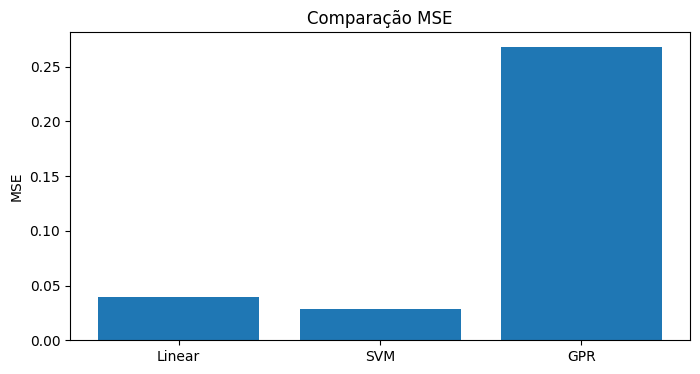

In [20]:
plt.figure(figsize=(8,4))
plt.bar(df_resultados["Modelo"], df_resultados["MSE"])
plt.title("Comparação MSE")
plt.ylabel("MSE")
plt.show()

Gráfico comparativo de RMSE

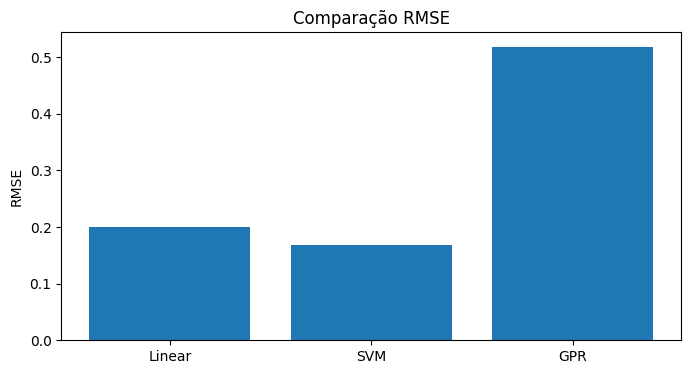

In [21]:
plt.figure(figsize=(8,4))
plt.bar(df_resultados["Modelo"], df_resultados["RMSE"])
plt.title("Comparação RMSE")
plt.ylabel("RMSE")
plt.show()

Foram comparados três algoritmos de regressão: Regressão Linear, Support Vector Regression (SVR) e Gaussian Process Regression (GPR). O coeficiente de determinação (R²) foi utilizado para avaliar a capacidade de explicação da variabilidade dos dados, enquanto MAE, MSE e RMSE foram empregados para medir o erro das previsões. Os resultados demonstram qual modelo melhor representa a relação entre comprimento e largura da pétala da base Iris. Modelos não lineares, como SVR e GPR, podem capturar padrões mais complexos que a regressão linear tradicional, resultando em melhor desempenho preditivo.